# 02 — Data Preprocessing

**Judul Penelitian:** Eksperimen Klasifikasi Depresi pada Remaja: Perbandingan Metode Feature Selection untuk Identifikasi Fitur Gaya Hidup Paling Berpengaruh

**Tujuan notebook ini:**
Menyiapkan data **siap pakai untuk eksperimen feature selection** (bukan perbandingan algoritma klasifikasi).

**Pipeline:**
1. Cleaning (missing values, outlier IQR)
2. Feature engineering (`screen_time_ratio`)
3. Encoding fitur kategorikal
4. Stratified train/test split (80:20)
5. Scaling:
   - **Standard Scaler** → untuk PCA & Mutual Information
   - **MinMax Scaler** → untuk Chi-Square (`SelectKBest(chi2)` memerlukan nilai non-negatif)

**Output untuk notebook 03:**
- `data/processed/train_scaled.csv`, `test_scaled.csv`
- `data/processed/train_minmax.csv`, `test_minmax.csv`
- `artifacts/` — scaler, daftar fitur, metadata

In [1]:
import json
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

RANDOM_STATE = 42
TEST_SIZE = 0.2
TARGET_COL = 'depression_label'

PROJECT_ROOT = Path('..').resolve()
DATA_PATH = PROJECT_ROOT / 'data' / 'Teen_Mental_Health_Dataset.csv'
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
ARTIFACTS_DIR = PROJECT_ROOT / 'artifacts'
FIGURES_DIR = PROJECT_ROOT / 'results' / 'figures'
TABLES_DIR = PROJECT_ROOT / 'results' / 'tables'

for folder in [PROCESSED_DIR, ARTIFACTS_DIR, FIGURES_DIR, TABLES_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print('Project root   :', PROJECT_ROOT)
print('Processed dir  :', PROCESSED_DIR)
print('Artifacts dir  :', ARTIFACTS_DIR)

Project root   : C:\Users\Nafan\Documents\Learn & Project\Kuliah\PM\Tugas Akhir\eksperimen-klasifikasi-depresi
Processed dir  : C:\Users\Nafan\Documents\Learn & Project\Kuliah\PM\Tugas Akhir\eksperimen-klasifikasi-depresi\data\processed
Artifacts dir  : C:\Users\Nafan\Documents\Learn & Project\Kuliah\PM\Tugas Akhir\eksperimen-klasifikasi-depresi\artifacts


In [2]:
df_raw = pd.read_csv(DATA_PATH)
print(f'Raw data: {df_raw.shape[0]} baris x {df_raw.shape[1]} kolom')
df_raw.head()

Raw data: 1500 baris x 13 kolom


,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,13,male,7.2,TikTok,4.1,1.3,2.49,1.8,medium,5,5,4,0
1,16,female,7.1,TikTok,5.5,1.1,2.11,0.3,medium,7,10,7,1
2,17,female,5.5,TikTok,7.9,1.6,2.78,0.3,low,5,9,7,0
3,18,male,7.2,Both,4.4,3.0,2.29,1.4,low,9,9,3,1
4,14,male,2.5,TikTok,5.6,2.9,2.24,0.5,low,3,9,5,0


## 1. Data Cleaning

In [3]:
df = df_raw.copy()

# 1.1 Missing values
missing_before = df.isnull().sum().sum()
print(f'Missing values sebelum cleaning: {missing_before}')

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

for col in numeric_cols:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].median())

for col in cat_cols:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].mode()[0])

print(f'Missing values setelah imputation: {df.isnull().sum().sum()}')

Missing values sebelum cleaning: 0
Missing values setelah imputation: 0


In [4]:
# 1.2 Outlier handling dengan IQR (clipping ke batas logis)
feature_numeric = [c for c in numeric_cols if c != TARGET_COL]
outlier_log = []

for col in feature_numeric:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    before_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    df[col] = df[col].clip(lower=lower, upper=upper)
    after_outliers = ((df[col] < lower) | (df[col] > upper)).sum()

    outlier_log.append({
        'fitur': col,
        'batas_bawah': round(lower, 2),
        'batas_atas': round(upper, 2),
        'outlier_sebelum': int(before_outliers),
        'outlier_sesudah': int(after_outliers),
    })

outlier_log_df = pd.DataFrame(outlier_log)
outlier_log_df

,fitur,batas_bawah,batas_atas,outlier_sebelum,outlier_sesudah
0,age,8.00,24.00,0,0
1,daily_social_media_hours,-2.25,11.75,0,0
2,sleep_hours,1.25,11.25,0,0
3,screen_time_before_sleep,-0.85,4.35,0,0
4,academic_performance,1.01,4.98,0,0
5,physical_activity,-1.00,3.00,0,0
6,stress_level,-4.50,15.50,0,0
7,anxiety_level,-4.50,15.50,0,0
8,addiction_level,-4.50,15.50,0,0


## 2. Feature Engineering

In [5]:
# Rasio paparan layar sebelum tidur terhadap jam tidur
# Nilai tinggi mengindikasikan gangguan ritme sirkadian

df['screen_time_ratio'] = (df['screen_time_before_sleep'] / df['sleep_hours']).round(3)

print('screen_time_ratio — statistik:')
print(df['screen_time_ratio'].describe().round(3))
df[['screen_time_before_sleep', 'sleep_hours', 'screen_time_ratio', TARGET_COL]].head()

screen_time_ratio — statistik:
count    1500.000
mean        0.292
std         0.143
min         0.056
25%         0.175
50%         0.273
75%         0.383
max         0.750
Name: screen_time_ratio, dtype: float64


,screen_time_before_sleep,sleep_hours,screen_time_ratio,depression_label
0,1.3,4.1,0.317,0
1,1.1,5.5,0.200,1
2,1.6,7.9,0.203,0
3,3.0,4.4,0.682,1
4,2.9,5.6,0.518,0


## 3. Encoding Fitur Kategorikal

In [6]:
df_encoded = df.copy()

# Binary encoding: gender (male=0, female=1)
df_encoded['gender'] = df_encoded['gender'].map({'male': 0, 'female': 1})

# Ordinal encoding: social_interaction_level
social_map = {'low': 0, 'medium': 1, 'high': 2}
df_encoded['social_interaction_level'] = df_encoded['social_interaction_level'].map(social_map)

# One-hot encoding: platform_usage
platform_dummies = pd.get_dummies(df_encoded['platform_usage'], prefix='platform', dtype=int)
df_encoded = pd.concat([df_encoded.drop(columns=['platform_usage']), platform_dummies], axis=1)

print('Kolom setelah encoding:')
print(df_encoded.columns.tolist())
df_encoded.head()

Kolom setelah encoding:
['age', 'gender', 'daily_social_media_hours', 'sleep_hours', 'screen_time_before_sleep', 'academic_performance', 'physical_activity', 'social_interaction_level', 'stress_level', 'anxiety_level', 'addiction_level', 'depression_label', 'screen_time_ratio', 'platform_Both', 'platform_Instagram', 'platform_TikTok']


,age,gender,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label,screen_time_ratio,platform_Both,platform_Instagram,platform_TikTok
0,13,0,7.2,4.1,1.3,2.49,1.8,1,5,5,4,0,0.317,0,0,1
1,16,1,7.1,5.5,1.1,2.11,0.3,1,7,10,7,1,0.200,0,0,1
2,17,1,5.5,7.9,1.6,2.78,0.3,0,5,9,7,0,0.203,0,0,1
3,18,0,7.2,4.4,3.0,2.29,1.4,0,9,9,3,1,0.682,1,0,0
4,14,0,2.5,5.6,2.9,2.24,0.5,0,3,9,5,0,0.518,0,0,1


In [7]:
# Pisahkan fitur dan target
feature_cols = [c for c in df_encoded.columns if c != TARGET_COL]
X = df_encoded[feature_cols]
y = df_encoded[TARGET_COL]

print(f'Jumlah fitur akhir: {len(feature_cols)}')
print('Fitur:', feature_cols)

Jumlah fitur akhir: 15
Fitur: ['age', 'gender', 'daily_social_media_hours', 'sleep_hours', 'screen_time_before_sleep', 'academic_performance', 'physical_activity', 'social_interaction_level', 'stress_level', 'anxiety_level', 'addiction_level', 'screen_time_ratio', 'platform_Both', 'platform_Instagram', 'platform_TikTok']


## 4. Stratified Train / Test Split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

print('Train set:', X_train.shape[0], 'sampel')
print('Test set :', X_test.shape[0], 'sampel')
print('\nDistribusi kelas — Train:')
print(y_train.value_counts(normalize=True).round(3))
print('\nDistribusi kelas — Test:')
print(y_test.value_counts(normalize=True).round(3))

Train set: 1200 sampel
Test set : 300 sampel

Distribusi kelas — Train:
depression_label
0    0.9
1    0.1
Name: proportion, dtype: float64

Distribusi kelas — Test:
depression_label
0    0.9
1    0.1
Name: proportion, dtype: float64


## 5. Scaling untuk Feature Selection

| Scaler | Digunakan untuk | Alasan |
|--------|-----------------|--------|
| **StandardScaler** | PCA, Mutual Information | Menyamakan skala fitur; PCA sensitif terhadap variansi |
| **MinMaxScaler** | Chi-Square | `chi2` di scikit-learn mensyaratkan fitur **non-negatif** |

Kedua scaler di-**fit hanya pada data latih** untuk mencegah data leakage.

In [9]:
# Fit scaler HANYA pada data latih untuk mencegah data leakage
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=feature_cols,
    index=X_train.index,
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=feature_cols,
    index=X_test.index,
)

compare_scale = pd.DataFrame({
    'fitur': feature_cols,
    'train_mean_sebelum': X_train.mean().round(3).values,
    'train_std_sebelum': X_train.std().round(3).values,
    'train_mean_sesudah': X_train_scaled.mean().round(3).values,
    'train_std_sesudah': X_train_scaled.std().round(3).values,
})
compare_scale

,fitur,train_mean_sebelum,train_std_sebelum,train_mean_sesudah,train_std_sesudah
0,age,15.922,2.045,0.0,1.0
1,gender,0.513,0.500,0.0,1.0
2,daily_social_media_hours,4.710,2.033,-0.0,1.0
3,sleep_hours,6.312,1.446,0.0,1.0
4,screen_time_before_sleep,1.758,0.715,0.0,1.0
5,academic_performance,2.996,0.573,-0.0,1.0
6,physical_activity,1.009,0.583,0.0,1.0
7,social_interaction_level,0.965,0.813,0.0,1.0
8,stress_level,5.696,2.966,-0.0,1.0
9,anxiety_level,5.897,2.881,0.0,1.0


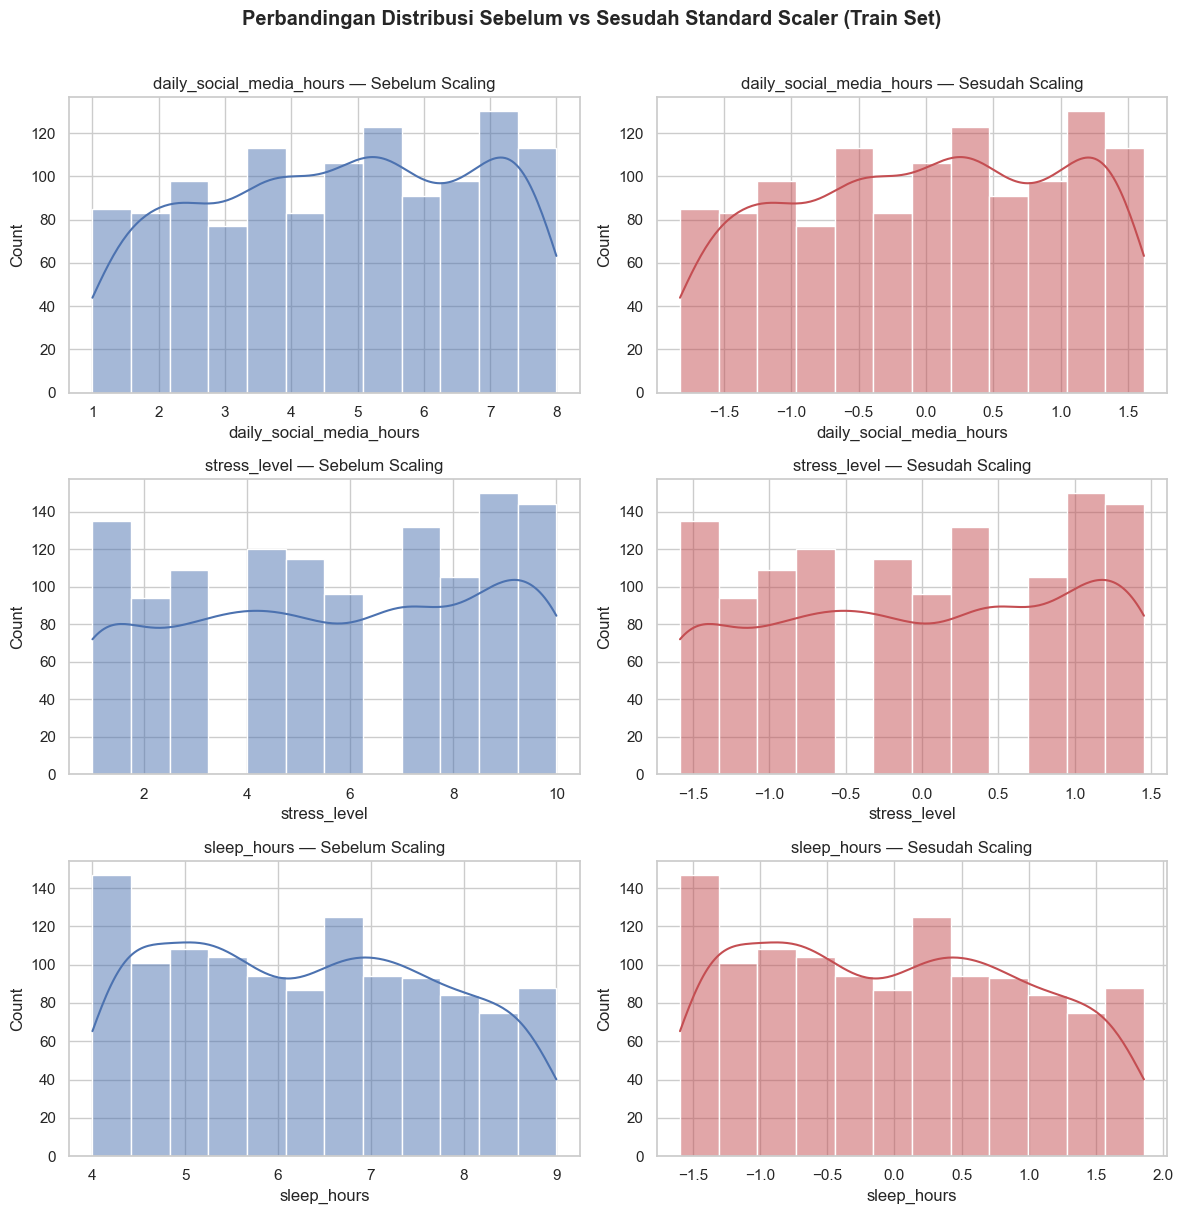

In [10]:
# Visualisasi perbandingan skala sebelum vs sesudah scaling (3 fitur contoh)
sample_features = ['daily_social_media_hours', 'stress_level', 'sleep_hours']

fig, axes = plt.subplots(len(sample_features), 2, figsize=(12, 4 * len(sample_features)))

for i, feat in enumerate(sample_features):
    sns.histplot(X_train[feat], kde=True, ax=axes[i, 0], color='#4C72B0')
    axes[i, 0].set_title(f'{feat} — Sebelum Scaling')
    sns.histplot(X_train_scaled[feat], kde=True, ax=axes[i, 1], color='#C44E52')
    axes[i, 1].set_title(f'{feat} — Sesudah Scaling')

plt.suptitle('Perbandingan Distribusi Sebelum vs Sesudah Standard Scaler (Train Set)', y=1.01, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '09_scaling_comparison.png', bbox_inches='tight')
plt.show()

In [ ]:
# MinMax Scaler untuk Chi-Square (fitur harus non-negatif)
from sklearn.preprocessing import MinMaxScaler

minmax_scaler = MinMaxScaler()
X_train_minmax = pd.DataFrame(
    minmax_scaler.fit_transform(X_train),
    columns=feature_cols,
    index=X_train.index,
)
X_test_minmax = pd.DataFrame(
    minmax_scaler.transform(X_test),
    columns=feature_cols,
    index=X_test.index,
)

print('MinMax range (train):', X_train_minmax.min().min(), 's/d', X_train_minmax.max().max())

## 6. Simpan Data & Artefak Preprocessing

In [11]:
# Simpan dataset processed
X_train.assign(**{TARGET_COL: y_train}).to_csv(PROCESSED_DIR / 'train_unscaled.csv', index=False)
X_test.assign(**{TARGET_COL: y_test}).to_csv(PROCESSED_DIR / 'test_unscaled.csv', index=False)
X_train_scaled.assign(**{TARGET_COL: y_train}).to_csv(PROCESSED_DIR / 'train_scaled.csv', index=False)
X_test_scaled.assign(**{TARGET_COL: y_test}).to_csv(PROCESSED_DIR / 'test_scaled.csv', index=False)
X_train_minmax.assign(**{TARGET_COL: y_train}).to_csv(PROCESSED_DIR / 'train_minmax.csv', index=False)
X_test_minmax.assign(**{TARGET_COL: y_test}).to_csv(PROCESSED_DIR / 'test_minmax.csv', index=False)

# Simpan scaler dan metadata
joblib.dump(scaler, ARTIFACTS_DIR / 'standard_scaler.joblib')
joblib.dump(minmax_scaler, ARTIFACTS_DIR / 'minmax_scaler.joblib')

metadata = {
    'research_focus': 'feature_selection_comparison',
    'target_col': TARGET_COL,
    'feature_cols': feature_cols,
    'random_state': RANDOM_STATE,
    'test_size': TEST_SIZE,
    'classifier_for_evaluation': 'RandomForest (class_weight=balanced)',
    'feature_selection_methods': ['all_features', 'PCA', 'chi2', 'mutual_info'],
    'data_files': {
        'scaled': 'train_scaled.csv / test_scaled.csv (PCA, Mutual Information)',
        'minmax': 'train_minmax.csv / test_minmax.csv (Chi-Square)',
        'unscaled': 'train_unscaled.csv / test_unscaled.csv (referensi)',
    },
    'encoding': {
        'gender': {'male': 0, 'female': 1},
        'social_interaction_level': social_map,
        'platform_usage': 'one-hot',
    },
    'train_samples': int(len(X_train)),
    'test_samples': int(len(X_test)),
}

with open(ARTIFACTS_DIR / 'preprocessing_metadata.json', 'w', encoding='utf-8') as f:
    json.dump(metadata, f, indent=2)

summary = pd.DataFrame({
    'tahap': [
        'Raw samples',
        'After cleaning',
        'Features after encoding',
        'Train samples',
        'Test samples',
        'Positive class (train)',
        'Positive class (test)',
    ],
    'nilai': [
        len(df_raw),
        len(df),
        len(feature_cols),
        len(X_train),
        len(X_test),
        int((y_train == 1).sum()),
        int((y_test == 1).sum()),
    ],
})

outlier_log_df.to_csv(TABLES_DIR / '06_outlier_clipping_log.csv', index=False)
compare_scale.to_csv(TABLES_DIR / '07_scaling_comparison.csv', index=False)
summary.to_csv(TABLES_DIR / '08_preprocessing_summary.csv', index=False)
pd.DataFrame({'feature': feature_cols}).to_csv(TABLES_DIR / '09_feature_columns.csv', index=False)

print('File tersimpan:')
for p in sorted(PROCESSED_DIR.glob('*.csv')):
    print(' ', p.name)
print('Artefak:', (ARTIFACTS_DIR / 'standard_scaler.joblib').name, ',', (ARTIFACTS_DIR / 'minmax_scaler.joblib').name)
summary

File tersimpan:
  test_scaled.csv
  test_unscaled.csv
  train_scaled.csv
  train_unscaled.csv
Artefak: standard_scaler.joblib


,tahap,nilai
0,Raw samples,1500
1,After cleaning,1500
2,Features after encoding,15
3,Train samples,1200
4,Test samples,300
5,Positive class (train),120
6,Positive class (test),30


## Ringkasan Preprocessing

Data siap untuk eksperimen **feature selection**:

1. **Cleaning** — Imputasi + clipping outlier IQR
2. **Feature Engineering** — `screen_time_ratio`
3. **Encoding** — binary, ordinal, one-hot
4. **Splitting** — Stratified 80/20 (`random_state=42`)
5. **Scaling** — StandardScaler (PCA, MI) + MinMaxScaler (Chi-Square)

| File | Penggunaan |
|------|------------|
| `train_scaled.csv` | PCA, Mutual Information |
| `train_minmax.csv` | Chi-Square (`SelectKBest(chi2)`) |
| `train_unscaled.csv` | Referensi / baseline all-features |

**Langkah berikutnya:** `03_experiment_feature_selection.ipynb`

**Output:**
- `data/processed/` — 6 file CSV (train/test × 3 versi)
- `artifacts/` — scaler, metadata, daftar fitur
- `results/tables/06_*.csv` s.d. `09_*.csv`